In [28]:
useful=['gold_standards_results.tblout',
        'PF00154_results.tblout',
        'PF00154_domain_results.tblout',]

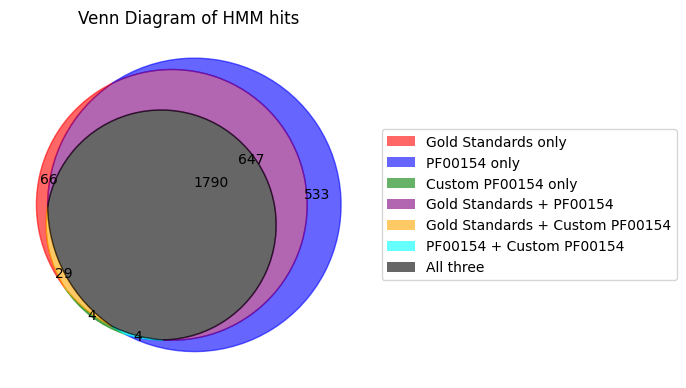

In [33]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn3
from matplotlib.patches import Patch

def read_tblout(filename):
    hits = set()

    with open(filename) as f:
        for line in f:
            if line.startswith("#"):
                continue
            fields = line.split()
            hits.add(fields[0])

    return hits


# Order:
# 1 = Gold Standards
# 2 = PF00154
# 3 = Custom PF00154

hmm1 = read_tblout(f'results/{useful[0]}')
hmm2 = read_tblout(f'results/{useful[1]}')
hmm3 = read_tblout(f'results/{useful[2]}')



v = venn3(
    [hmm1, hmm2, hmm3],
    set_labels=None,
)


# Colour each region according to the sets it contains
region_colours = {
    '100': 'red',       # Gold Standards only
    '010': 'blue',      # PF00154 only
    '001': 'green',     # Custom PF00154 only

    '110': 'purple',    # Gold Standards + PF00154
    '101': 'orange',    # Gold Standards + Custom PF00154
    '011': 'cyan',      # PF00154 + Custom PF00154

    '111': 'black'      # All three
}


for region, colour in region_colours.items():
    patch = v.get_patch_by_id(region)

    if patch is not None:
        patch.set_color(colour)
        patch.set_alpha(0.6)


# Legend
legend_handles = [
    Patch(
        facecolor='red',
        alpha=0.6,
        label='Gold Standards only'
    ),
    Patch(
        facecolor='blue',
        alpha=0.6,
        label='PF00154 only'
    ),
    Patch(
        facecolor='green',
        alpha=0.6,
        label='Custom PF00154 only'
    ),
    Patch(
        facecolor='purple',
        alpha=0.6,
        label='Gold Standards + PF00154'
    ),
    Patch(
        facecolor='orange',
        alpha=0.6,
        label='Gold Standards + Custom PF00154'
    ),
    Patch(
        facecolor='cyan',
        alpha=0.6,
        label='PF00154 + Custom PF00154'
    ),
    Patch(
        facecolor='black',
        alpha=0.6,
        label='All three'
    )
]


# Put legend outside the Venn
plt.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)


plt.title("Venn Diagram of HMM hits")

plt.tight_layout()

plt.savefig(
    'plots/hmm_venn.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

In [9]:
import pandas as pd
df=pd.read_csv('../3-InSilicoScreening/scoring_results/top_hits_tp.csv')

In [12]:
df['tOPT'].mean()

np.float64(43.11690046760187)